In [ ]:
from pathlib import Path
import json
import fluidbench

import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
ID = "cylinder_Re41_interp"

RANDOM_STATE = 42
BATCH_SIZE = 8

In [ ]:
# Optional
# dataset_path = fluidbench.load(ID)
# print(f"Dataset files are available at {dataset_path.resolve()}")


train.h5: reconstructing file:   0%|          |  0.00B / 2.79MB            

train.h5: downloading bytes:           |  0.00B            

validation.h5: reconstructing file:   0%|          |  0.00B /  347kB            

validation.h5: downloading bytes:           |  0.00B            

test.h5: reconstructing file:   0%|          |  0.00B /  343kB            

test.h5: downloading bytes:           |  0.00B            

Dataset files are available at C:\Users\pabloac\Desktop\TRANSDIFFUSE\FluidBench\tests\cylinder_Re41_interp


In [5]:
class CFDataset(Dataset):
    def __init__(self, scalars, fields, targets, indices):
        self.scalars = scalars[indices]
        self.fields = fields[indices]
        self.targets = targets[indices]

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        X = (
            torch.as_tensor(self.scalars[i]),
            torch.as_tensor(self.fields[i]),
        )
        y = torch.as_tensor(self.targets[i])
        return X, y

In [7]:
### Training
from minimal_models import BaselineZero as architecture

model = architecture()
model.to(model.device)

BaselineZero(
  (loss): MSELoss()
  (loss_unreduced): MSELoss()
)

In [8]:
model.total_parameters

1

In [9]:
history = model.fit(
    train_dataloader,
    val_dataloader
)

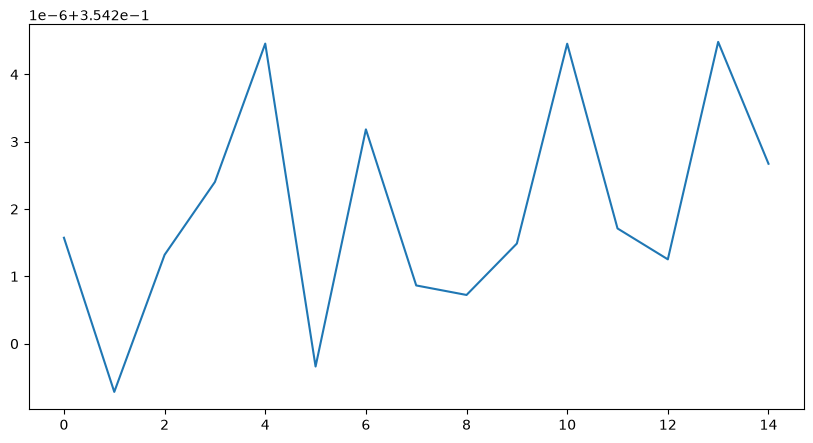

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(history["train_epochs"], history["train_losses"], label="Train Loss")
plt.show()